#### Unit Commitment with CPLEX Direct
#### Modular Architecture

## 01. Import Libary
Bagian ini memuat seluruh library yang digunakan untuk:
- pemodelan optimasi UC,
- visualisasi,
- post-processing,
- simulasi frekuensi,
- dan komunikasi solver CPLEX Direct.

In [1286]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
# Bagian ini memuat seluruh library yang digunakan dalam model UC,
# post-processing, dan simulasi frekuensi.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyomo.environ import (
    ConcreteModel, Set, Param, Var,
    Constraint, Objective,
    NonNegativeReals, Binary,
    SolverFactory, minimize, value
)

from pyomo.opt import SolverStatus, TerminationCondition

## Tes CPLEX Direct

In [1287]:
# =========================================================
# TEST CPLEX DIRECT
# =========================================================

import cplex
print("CPLEX Version:", cplex.__version__)

from pyomo.environ import SolverFactory

solver_test = SolverFactory("cplex_direct")

print("CPLEX Direct Available:", solver_test.available())

CPLEX Version: 22.1.1.0
CPLEX Direct Available: True


## 02. Konfigurasi Skenario
Bagian ini mengatur:
- solver,
- komponen fungsi objektif,
- aktivasi constraint,
- konfigurasi reserve,
- dan pengaturan simulasi.

Pendekatan modular digunakan agar setiap fitur dapat diaktifkan/nonaktifkan tanpa mengubah struktur model utama.

In [1288]:
# ============================================================
# 2. SCENARIO CONFIGURATION
# ============================================================

CONFIG = {
    # Solver
    "solver": "cplex_direct",
    "tee": False,
    "mipgap": 0.001,
    "timelimit": 300,
    
    # Objective components
    "obj_generation_cost": True,
    "obj_fixed_cost": True,
    "obj_startup_cost": True,
    "obj_shutdown_cost": True,
    "obj_reserve_cost": False,
    "obj_curtailment_cost": False,

    # Constraint activation
    "con_power_balance": True,
    "con_capacity_upper": True,
    "con_capacity_lower": True,
    "con_startup_shutdown_logic": True,
    "con_ramp_up": True,
    "con_ramp_down": True,
    "con_minimum_up_time": True,
    "con_minimum_down_time": False,

    #"con_spinning_reserve": False,
    "con_reserve_headroom": True,
    "con_n1_security": True,
    "con_reserve_ramp_capability": True,
    #"con_renewable_limit": False,
    
    "con_curtailment_limit": True,
    
    "con_pfr_within_reserve": True,
    "con_pfr_governor_only": True,
    "con_pfr_headroom": True,
    "con_pfr_ramp_capability": True,

    #"con_pfr_requirement": False,
    #"con_frequency_security": False,
    #"con_frequency_deviation": False,

    "con_pfr_capacity": False,
    # Reserve settings
    "reserve_response_time": 60/60,
    "pfr_response_time": 10/60,
}

# ============================================================
# PARAMETER FREKUENSI DAN SIMULASI
# ============================================================

f0 = 50.0
f_min = 49.5
df_max = f0 - f_min

D_frac = 0.01
sim_time = 200
dt = 0.02

t_uc = 8

3. Read Data Excel

In [1289]:
# ============================================================
# 3. READ DATA FROM EXCEL
# ============================================================
# Bagian ini membaca data generator dan demand dari file Excel.

file_path = r"D:\UGM\Tugas Akhir\UC Coding\Belajar\DataSet_ModifikasiCandra_R00.xlsx"

gen_df = pd.read_excel(file_path, sheet_name="Gen")
demand_df = pd.read_excel(file_path, sheet_name="Demand")

# Cek cepat isi data
# print(gen_df.head())
# print(demand_df.head())

4. Validasi Kolom Data

In [1290]:
# ============================================================
# 4. DATA VALIDATION
# ============================================================
# Bagian ini memastikan semua kolom wajib tersedia.
# Tujuannya agar error lebih mudah dilacak sebelum masuk ke Pyomo.

required_gen_cols = [
    "Unit", "Pmin", "Pmax", "a", "b", "c",
    "SU_Cost", "SD_Cost",
    "Ramp_Up", "Ramp_Down",
    "Min_Up", "Min_Down",
    "Droop", "PFR_Fraction", "FreeGovernor",
    "Type", "H", "Tg"
]

required_demand_cols = [
    "Hour", "Demand", "Potensi PV (MW)", "Potensi WT (MW)"
]

missing_gen_cols = [col for col in required_gen_cols if col not in gen_df.columns]
missing_demand_cols = [col for col in required_demand_cols if col not in demand_df.columns]

if missing_gen_cols:
    raise ValueError(f"Kolom hilang pada sheet Gen: {missing_gen_cols}")

if missing_demand_cols:
    raise ValueError(f"Kolom hilang pada sheet Demand: {missing_demand_cols}")

5. Konversi DataFrame ke Dictionary

In [1291]:
# ============================================================
# 5. CONVERT DATAFRAME TO DICTIONARY
# ============================================================
# Bagian ini mengubah data pandas menjadi dictionary agar mudah
# digunakan sebagai Pyomo Param.

G = gen_df["Unit"].tolist()
T = demand_df["Hour"].tolist()

# Parameter generator
Pmin = dict(zip(gen_df["Unit"], gen_df["Pmin"]))
Pmax = dict(zip(gen_df["Unit"], gen_df["Pmax"]))

a = dict(zip(gen_df["Unit"], gen_df["a"]))
b = dict(zip(gen_df["Unit"], gen_df["b"]))
c = dict(zip(gen_df["Unit"], gen_df["c"]))

SU_cost = dict(zip(gen_df["Unit"], gen_df["SU_Cost"]))
SD_cost = dict(zip(gen_df["Unit"], gen_df["SD_Cost"]))

RampUp = dict(zip(gen_df["Unit"], gen_df["Ramp_Up"]))
RampDown = dict(zip(gen_df["Unit"], gen_df["Ramp_Down"]))

MinUp = dict(zip(gen_df["Unit"], gen_df["Min_Up"]))
MinDown = dict(zip(gen_df["Unit"], gen_df["Min_Down"]))

Droop = dict(zip(gen_df["Unit"], gen_df["Droop"]))
PFR_Fraction = dict(zip(gen_df["Unit"], gen_df["PFR_Fraction"]))
FreeGovernor = dict(zip(gen_df["Unit"], gen_df["FreeGovernor"]))

Type = dict(zip(gen_df["Unit"], gen_df["Type"]))
H = dict(zip(gen_df["Unit"], gen_df["H"]))
Tg = dict(zip(gen_df["Unit"], gen_df["Tg"]))

# Parameter demand
Demand = dict(zip(demand_df["Hour"], demand_df["Demand"]))

PV_Potential = dict(zip(demand_df["Hour"], demand_df["Potensi PV (MW)"]))
WT_Potential = dict(zip(demand_df["Hour"], demand_df["Potensi WT (MW)"]))

6. Parameter Turunan

In [1292]:
# ============================================================
# 6. DERIVED PARAMETERS
# ============================================================
# Bagian ini menghitung parameter turunan sebelum masuk model Pyomo.

# Potensi renewable per unit dan waktu
RenewPotential = {}

for g in G:
    for t in T:
        if Type[g] == "PV":
            RenewPotential[g, t] = PV_Potential[t]
        elif Type[g] == "WT":
            RenewPotential[g, t] = WT_Potential[t]
        else:
            RenewPotential[g, t] = Pmax[g]

# Batas maksimum PFR tiap unit
PFR_Max = {
    g: PFR_Fraction[g] * Pmax[g]
    for g in G
}

# Frequency bias tiap generator
# Satuan: MW/Hz
FreqBias = {}

for g in G:
    if Droop[g] > 0 and FreeGovernor[g] == 1:
        FreqBias[g] = Pmax[g] / (Droop[g] * f0)
    else:
        FreqBias[g] = 0

# Biaya reserve sederhana
ReserveCost = {
    g: 0.10 * b[g]
    for g in G
}

7. Definisi Model dan Set

In [1293]:
# ============================================================
# 7. MODEL AND SETS
# ============================================================
# Bagian ini membuat model Pyomo dan mendefinisikan set generator serta waktu.

model = ConcreteModel()

model.G = Set(initialize=G)
model.T = Set(initialize=T)

8. Parameter Pyomo

In [1294]:
# ============================================================
# 8. PYOMO PARAMETERS
# ============================================================
# Bagian ini memasukkan parameter numerik ke dalam model Pyomo.

model.Pmin = Param(model.G, initialize=Pmin)
model.Pmax = Param(model.G, initialize=Pmax)

model.a = Param(model.G, initialize=a)
model.b = Param(model.G, initialize=b)
model.c = Param(model.G, initialize=c)

model.SU_cost = Param(model.G, initialize=SU_cost)
model.SD_cost = Param(model.G, initialize=SD_cost)

model.RampUp = Param(model.G, initialize=RampUp)
model.RampDown = Param(model.G, initialize=RampDown)

model.MinUp = Param(model.G, initialize=MinUp)
model.MinDown = Param(model.G, initialize=MinDown)

model.Demand = Param(model.T, initialize=Demand)

model.Droop = Param(model.G, initialize=Droop, within=NonNegativeReals)
model.PFR_Fraction = Param(model.G, initialize=PFR_Fraction, within=NonNegativeReals)
model.FreeGovernor = Param(model.G, initialize=FreeGovernor, within=Binary)
model.PFR_Max = Param(model.G, initialize=PFR_Max, within=NonNegativeReals)

model.FreqBias = Param(model.G, initialize=FreqBias)
model.ReserveCost = Param(model.G, initialize=ReserveCost)

model.RenewPotential = Param(model.G, model.T, initialize=RenewPotential, within=NonNegativeReals)

model.H = Param(model.G, initialize=H)
model.Tg = Param(model.G, initialize=Tg)

9. Variabel Keputusan UC

In [1295]:
# ============================================================
# 9. DECISION VARIABLES
# ============================================================
# Bagian ini mendefinisikan variabel keputusan model UC.
# Semua variabel di sini memengaruhi hasil optimasi.

model.P = Var(model.G, model.T, domain=NonNegativeReals)       # output daya unit
model.u = Var(model.G, model.T, domain=Binary)                 # status ON/OFF unit
model.y = Var(model.G, model.T, domain=Binary)                 # startup
model.z = Var(model.G, model.T, domain=Binary)                 # shutdown

model.R = Var(model.G, model.T, within=NonNegativeReals)       # spinning reserve
model.Curt = Var(model.G, model.T, within=NonNegativeReals)    # renewable curtailment

# R_pfr hanya digunakan jika skenario PFR aktif.
model.R_pfr = Var(model.G, model.T, within=NonNegativeReals)   # primary frequency reserve

In [1296]:
print(CONFIG)

{'solver': 'cplex_direct', 'tee': False, 'mipgap': 0.001, 'timelimit': 300, 'obj_generation_cost': True, 'obj_fixed_cost': True, 'obj_startup_cost': True, 'obj_shutdown_cost': True, 'obj_reserve_cost': False, 'obj_curtailment_cost': False, 'con_power_balance': True, 'con_capacity_upper': True, 'con_capacity_lower': True, 'con_startup_shutdown_logic': True, 'con_ramp_up': True, 'con_ramp_down': True, 'con_minimum_up_time': True, 'con_minimum_down_time': False, 'con_reserve_headroom': True, 'con_n1_security': True, 'con_reserve_ramp_capability': True, 'con_curtailment_limit': True, 'con_pfr_within_reserve': True, 'con_pfr_governor_only': True, 'con_pfr_headroom': True, 'con_pfr_ramp_capability': True, 'con_pfr_capacity': False, 'reserve_response_time': 1.0, 'pfr_response_time': 0.16666666666666666}


## 10. Objective Function
Fungsi objektif dibuat modular sehingga setiap komponen biaya dapat diaktifkan atau dinonaktifkan melalui dictionary `CONFIG`.

Komponen biaya yang tersedia:
- biaya pembangkitan,
- biaya fixed/no-load,
- startup cost,
- shutdown cost,
- reserve cost,
- dan biaya lain yang dapat ditambahkan pada tahap berikutnya.

In [1297]:
# ============================================================
# 10. OBJECTIVE FUNCTION
# ============================================================

def obj_rule(m):

    total_cost = 0

    # ========================================================
    # Generation Cost
    # ========================================================
    if CONFIG["obj_generation_cost"]:

        total_cost += sum(
            m.b[g] * m.P[g, t]
            for g in m.G
            for t in m.T
        )

    # ========================================================
    # Fixed / No-load Cost
    # ========================================================
    if CONFIG["obj_fixed_cost"]:

        total_cost += sum(
            m.c[g] * m.u[g, t]
            for g in m.G
            for t in m.T
        )

    # ========================================================
    # Startup Cost
    # ========================================================
    if CONFIG["obj_startup_cost"]:

        total_cost += sum(
            m.SU_cost[g] * m.y[g, t]
            for g in m.G
            for t in m.T
        )

    # ========================================================
    # Shutdown Cost
    # ========================================================
    if CONFIG["obj_shutdown_cost"]:

        total_cost += sum(
            m.SD_cost[g] * m.z[g, t]
            for g in m.G
            for t in m.T
        )

    # ========================================================
    # Reserve Cost
    # ========================================================
    if CONFIG["obj_reserve_cost"]:

        total_cost += sum(
            m.ReserveCost[g] * m.R[g, t]
            for g in m.G
            for t in m.T
        )

    return total_cost

# Hapus objective lama jika cell dijalankan ulang
if hasattr(model, "Obj"):
    model.del_component(model.Obj)

model.Obj = Objective(
    rule=obj_rule,
    sense=minimize
)

## 11. Constraint UC Dasar
Bagian ini berisi constraint utama Unit Commitment.

In [1298]:
# ----------------------------
# 11.1 Power Balance
# ----------------------------
# Total pembangkitan harus sama dengan demand setiap jam.

if hasattr(model, "Balance"):
    model.del_component(model.Balance)

if CONFIG["con_power_balance"]:

    def balance_rule(m, t):
        return sum(m.P[g, t] for g in m.G) == m.Demand[t]

    model.Balance = Constraint(model.T, rule=balance_rule)

In [1299]:
# ----------------------------
# 11.2 Capacity Upper Bound
# ----------------------------
# Output unit tidak boleh melebihi kapasitas maksimum saat unit ON.
# Untuk PV dan WT, batasnya mengikuti potensi renewable.

if hasattr(model, "MaxCap"):
    model.del_component(model.MaxCap)
    
if CONFIG["con_capacity_upper"]:

    def max_rule(m, g, t):
        if Type[g] in ["PV", "WT"]:
            return m.P[g, t] <= m.RenewPotential[g, t]
        else:
            return m.P[g, t] <= m.Pmax[g] * m.u[g, t]

    model.MaxCap = Constraint(model.G, model.T, rule=max_rule)

In [1300]:
# ----------------------------
# 11.3 Capacity Lower Bound
# ----------------------------
# Output thermal unit minimal Pmin saat unit ON.
# PV dan WT tidak dipaksa memiliki Pmin.

if hasattr(model, "MinCap"):
    model.del_component(model.MinCap)
    
if CONFIG["con_capacity_lower"]:

    def min_rule(m, g, t):
        if Type[g] in ["PV", "WT"]:
            return m.P[g, t] >= 0
        else:
            return m.P[g, t] >= m.Pmin[g] * m.u[g, t]

    model.MinCap = Constraint(model.G, model.T, rule=min_rule)

In [1301]:
# ----------------------------
# 11.4 Startup and Shutdown Transition
# ----------------------------
# Menghubungkan perubahan status unit dengan startup dan shutdown.

if hasattr(model, "StartupShutdown"):
    model.del_component(model.StartupShutdown)

if CONFIG["con_startup_shutdown_logic"]:

    def startup_shutdown_rule(m, g, t):
        if t == m.T.first():
            return m.y[g, t] - m.z[g, t] == m.u[g, t]
        else:
            return m.y[g, t] - m.z[g, t] == m.u[g, t] - m.u[g, t-1]

    model.Transition = Constraint(model.G, model.T, rule=startup_shutdown_rule)

In [1302]:
# ----------------------------
# 11.5 Ramp Up
# ----------------------------
# Membatasi kenaikan daya antar jam.

if hasattr(model, "RampUpConstraint"):
    model.del_component(model.RampUpConstraint)

if CONFIG["con_ramp_up"]:

    def ramp_up_rule(m, g, t):

        if t == m.T.first():
            return Constraint.Skip
        
        return (
            m.P[g,t] - m.P[g, t-1] 
            <= m.RampUp[g]
        )
    
    model.RampUpConstraint = Constraint(model.G, model.T, rule=ramp_up_rule)

In [1303]:
# ----------------------------
# 11.6 Ramp Down
# ----------------------------
# Membatasi penurunan daya antar jam.

if hasattr(model, "RampDownConstraint"):
    model.del_component(model.RampDownConstraint)

if CONFIG["con_ramp_down"]:

    def ramp_down_rule(m, g, t):

        if t == m.T.first():
            return Constraint.Skip

        return (
            m.P[g, t-1] - m.P[g, t]
            <= m.RampDown[g]
        )

    model.RampDownConstraint = Constraint(model.G, model.T, rule=ramp_down_rule)

In [1304]:
# ----------------------------
# 11.7 Minimum Up Time
# ----------------------------
# Unit yang baru startup harus tetap ON
# selama minimum up time.

if hasattr(model, "MinUpTime"):
    model.del_component(model.MinUpTime)

if CONFIG["con_minimum_up_time"]:

    def min_up_time_rule(m, g, t):

        UT = int(MinUp[g])

        if t > len(m.T) - UT + 1:
            return Constraint.Skip

        return (
            sum(m.u[g, tau] for tau in range(t, t + UT))
            >= UT * m.y[g, t]
        )

    model.MinUpTime = Constraint(model.G, model.T, rule=min_up_time_rule)

In [1305]:
# ----------------------------
# 11.8 Minimum Down Time
# ----------------------------
# Jika unit shutdown, maka unit harus OFF minimal selama MinDown.

if hasattr(model, "MinDownTime"):
    model.del_component(model.MinDownTime)

if CONFIG["con_minimum_down_time"]:

    def min_down_time_rule(m, g, t):

        DT = int(MinDown[g])

        if t > len(m.T) - DT + 1:
            return Constraint.Skip

        return (
            sum(1 - m.u[g, tau] for tau in range(t, t + DT))
            >= DT * m.z[g, t]
        )

    model.MinDownTime = Constraint(model.G, model.T, rule=min_down_time_rule)

## 12. Contraint Reserve
Bagian ini mengatur reserve

In [1306]:
# ----------------------------
# 12.1 Reserve Headroom
# ----------------------------
# Reserve hanya boleh berasal dari kapasitas kosong unit thermal.
# PV dan WT tidak menyediakan spinning reserve dalam model ini.

if hasattr(model, "ReserveHeadroom"):
    model.del_component(model.ReserveHeadroom)

if CONFIG["con_reserve_headroom"]:

    def reserve_headroom_rule(m, g, t):

        return (
            m.P[g, t] + m.R[g, t]
            <= m.Pmax[g] * m.u[g, t]
        )

    model.ReserveHeadroom = Constraint(model.G, model.T, rule=reserve_headroom_rule)

In [1307]:
# ----------------------------
# 12.2 N-1 Reserve Constraint
# ----------------------------
# Reserve dari unit lain harus cukup untuk menutup kehilangan unit thermal terbesar.
# Constraint ini membuat model lebih aman terhadap kontingensi unit terbesar.

if hasattr(model, "N1Reserve"):
    model.del_component(model.N1Reserve)

if CONFIG["con_n1_security"]:

    def n1_reserve_rule(m, outage_g, t):

        if Type[outage_g] not in ["PV", "WT"]:
            return sum(
                m.R[g, t]
                for g in m.G
                if g != outage_g and Type[g] not in ["PV", "WT"]
            ) >= m.P[outage_g, t]
        else:
            return Constraint.Skip

    model.N1Reserve = Constraint(model.G, model.T, rule=n1_reserve_rule)

In [1308]:
# ----------------------------
# 12.3 Reserve Ramp Capability
# ----------------------------
# Reserve tidak boleh melebihi kemampuan ramp-up unit.

if hasattr(model, "ReserveRampCapability"):
    model.del_component(model.ReserveRampCapability)

if CONFIG["con_reserve_ramp_capability"]:

    def reserve_ramp_capability_rule(m, g, t):
        return m.R[g, t] <= m.RampUp[g] * CONFIG["reserve_response_time"]

    model.ReserveRampCapability = Constraint(
        model.G,
        model.T,
        rule=reserve_ramp_capability_rule
    )

## 13. Renewable & Curtailment
Curtailment = potensi renewable - dispatch renewable.

In [1309]:
# ----------------------------.
# 13.1 Renewable Curtailment
# ----------------------------
# Curtailment = potensi renewable - dispatch renewable.

if hasattr(model, "Curtailment"):
    model.del_component(model.Curtailment)

if CONFIG["con_curtailment_limit"]:

    def curtailment_rule(m, g, t):
        if Type[g] in ["PV", "WT"]:
            return m.Curt[g, t] == m.RenewPotential[g, t] - m.P[g, t]
        else:
            return m.Curt[g, t] == 0

    model.Curtailment = Constraint(model.G, model.T, rule=curtailment_rule)

## 14. Constraint PFR/FCUC
Bagian ini memodelkan kemampuan sistem dalam menjaga stabilitas frekuensi
setelah terjadi gangguan pembangkit atau ketidakseimbangan daya.

Primary Frequency Response (PFR) disediakan oleh unit pembangkit yang
memiliki governor dan reserve yang cukup untuk merespons deviasi frekuensi.

Constraint pada bagian ini bertujuan untuk:
- memastikan reserve dapat digunakan untuk PFR,
- membatasi partisipasi hanya pada unit dengan governor,
- menjaga kecukupan respons frekuensi sistem,
- dan mendukung studi Frequency-Constrained Unit Commitment (FCUC).

In [1310]:
# ----------------------------
# 14.1 PFR Within Reserve
# ----------------------------
# PFR tidak boleh melebihi reserve yang tersedia.

if hasattr(model, "PFRWithinReserve"):
    model.del_component(model.PFRWithinReserve)

if CONFIG["con_pfr_within_reserve"]:

    def pfr_within_reserve_rule(m, g, t):
        return m.R_pfr[g, t] <= m.R[g, t]

    model.PFRWithinReserve = Constraint(
        model.G,
        model.T,
        rule=pfr_within_reserve_rule
    )

In [1311]:
# ----------------------------
# 14.2 PFR Governor Capability
# ----------------------------
# Hanya unit dengan free governor yang dapat menyediakan PFR.

if hasattr(model, "PFRGovernorCapability"):
    model.del_component(model.PFRGovernorCapability)

if CONFIG["con_pfr_governor_only"]:

    def pfr_governor_capability_rule(m, g, t):
        return (
            m.R_pfr[g, t]
            <= m.PFR_Max[g] * m.FreeGovernor[g] * m.u[g, t]
        )

    model.PFRGovernorCapability = Constraint(
        model.G,
        model.T,
        rule=pfr_governor_capability_rule
    )

In [1312]:
# ----------------------------
# 14.3 PFR Headroom
# ----------------------------
# PFR harus tersedia dari headroom unit.

if hasattr(model, "PFRHeadroom"):
    model.del_component(model.PFRHeadroom)

if CONFIG["con_pfr_headroom"]:

    def pfr_headroom_rule(m, g, t):
        return (
            m.P[g, t] + m.R_pfr[g, t]
            <= m.Pmax[g] * m.u[g, t]
        )

    model.PFRHeadroom = Constraint(
        model.G,
        model.T,
        rule=pfr_headroom_rule
    )

In [1313]:
# ----------------------------
# 14.4 PFR Ramp Capability
# ----------------------------
# PFR tidak boleh melebihi kemampuan ramp-up unit
# dalam waktu respons PFR tertentu.

if hasattr(model, "PFRRampCapability"):
    model.del_component(model.PFRRampCapability)

if CONFIG["con_pfr_ramp_capability"]:

    def pfr_ramp_capability_rule(m, g, t):
        return (
            m.R_pfr[g, t]
            <= m.RampUp[g] * CONFIG["pfr_response_time"]
        )

    model.PFRRampCapability = Constraint(
        model.G,
        model.T,
        rule=pfr_ramp_capability_rule
    )

In [1314]:
# ============================================================
# 13. PFR CONSTRAINTS
# ============================================================
# Bagian ini hanya aktif jika use_pfr = True.
# PFR di sini masih berupa alokasi reserve, bukan simulasi frekuensi dinamik.

if CONFIG["con_pfr_capacity"]:

    # PFR tidak boleh melebihi headroom unit
    def pfr_headroom_rule(m, g, t):
        return m.R_pfr[g, t] <= m.Pmax[g] * m.u[g, t] - m.P[g, t]

    model.PFR_Headroom = Constraint(model.G, model.T, rule=pfr_headroom_rule)


    # PFR dibatasi kemampuan governor dan status ON unit
    def pfr_cap_rule(m, g, t):
        return m.R_pfr[g, t] <= m.PFR_Max[g] * m.FreeGovernor[g] * m.u[g, t]

    model.PFR_Cap = Constraint(model.G, model.T, rule=pfr_cap_rule)


    # PFR harus merupakan bagian dari spinning reserve
    def pfr_within_reserve_rule(m, g, t):
        return m.R_pfr[g, t] <= m.R[g, t]

    model.PFR_Within_Reserve = Constraint(model.G, model.T, rule=pfr_within_reserve_rule)

else:

    # Jika skenario PFR tidak aktif, R_pfr dipaksa nol.
    def no_pfr_rule(m, g, t):
        return m.R_pfr[g, t] == 0

    model.NoPFR = Constraint(model.G, model.T, rule=no_pfr_rule)

14. Solve Model

In [1315]:
# ============================================================
# 14. SOLVE MODEL
# ============================================================
# Bagian ini menjalankan solver MILP.

solver = SolverFactory("cplex_direct")
results = solver.solve(model, tee=False)

if (
    results.solver.status == SolverStatus.ok
    and results.solver.termination_condition == TerminationCondition.optimal
):
    print("Optimal solution found.")
else:
    print("Model infeasible or not optimal.")
    print(results.solver.status)
    print(results.solver.termination_condition)

Optimal solution found.


15-Build Result DataFrame

In [1316]:
# ============================================================
# 15. BUILD RESULT DATAFRAME
# ============================================================
# Bagian ini mengambil hasil optimasi dari Pyomo dan menyusunnya
# menjadi dataframe agar mudah dibaca, dicetak, dan diplot.

def fmt(x):
    if abs(x - round(x)) < 1e-6:
        return int(round(x))
    return round(x, 2)


rows = []

for t in model.T:
    row = {
        "Hour": t,
        "Demand": fmt(value(model.Demand[t]))
    }

    total_power = 0
    total_reserve = 0
    total_pfr = 0

    fuel_cost = 0
    fixed_cost = 0
    startup_cost = 0
    shutdown_cost = 0
    reserve_cost = 0

    for g in model.G:
        p = value(model.P[g, t])
        u = value(model.u[g, t])
        y = value(model.y[g, t])
        z = value(model.z[g, t])
        r = value(model.R[g, t])
        r_pfr = value(model.R_pfr[g, t])

        row[f"{g}_P"] = fmt(p)
        row[f"{g}_U"] = fmt(u)
        row[f"{g}_Y"] = fmt(y)
        row[f"{g}_Z"] = fmt(z)
        row[f"{g}_R"] = fmt(r)
        row[f"{g}_PFR"] = fmt(r_pfr)
        row[f"{g}_Headroom"] = fmt(value(model.Pmax[g]) * u - p)

        if Type[g] in ["PV", "WT"]:
            row[f"{g}_Curt"] = fmt(value(model.Curt[g, t]))

        total_power += p
        total_reserve += r
        total_pfr += r_pfr

        fuel_cost += p * value(model.b[g])
        fixed_cost += u * value(model.c[g])
        startup_cost += y * value(model.SU_cost[g])
        shutdown_cost += z * value(model.SD_cost[g])
        reserve_cost += r * value(model.ReserveCost[g])

    row["Total_Power"] = fmt(total_power)
    row["Total_Reserve"] = fmt(total_reserve)
    row["Total_PFR"] = fmt(total_pfr)

    row["Contingency"] = fmt(max(
        value(model.P[g, t])
        for g in model.G
        if Type[g] not in ["PV", "WT"]
    ))

    row["Reserve_Margin"] = fmt(row["Total_Reserve"] - row["Contingency"])

    row["Fuel Cost"] = fmt(fuel_cost)
    row["Fixed Cost"] = fmt(fixed_cost)
    row["Startup Cost"] = fmt(startup_cost)
    row["Shutdown Cost"] = fmt(shutdown_cost)
    row["Reserve Cost"] = fmt(reserve_cost)
    row["Total Cost"] = fmt(
        fuel_cost + fixed_cost + startup_cost + shutdown_cost + reserve_cost
    )

    rows.append(row)

df_hourly = pd.DataFrame(rows)

16-Tabel Hasil UC

In [1317]:
# ============================================================
# 16. UC RESULT TABLES
# ============================================================
# Bagian ini menampilkan tabel dispatch, status unit, reserve, biaya,
# ramping, dan ringkasan sistem.

# ----------------------------
# 16.1 Tabel Dispatch
# ----------------------------

print("\n========== TABEL A: DISPATCH ==========")

dispatch_cols = ["Hour", "Demand"] + [f"{g}_P" for g in model.G] + ["Total_Power"]
print(df_hourly[dispatch_cols].to_string(index=False))


========== TABEL A: DISPATCH ==========
 Hour  Demand  G1_P  G2_P   G3_P  G4_P  G5_P   G6_P   G7_P   G8_P  G9_P  G10_P  Total_Power
    1 4225.68   960     0 849.00     0     0   0.00 473.68 473.00   750 720.00      4225.68
    2 4173.17   849     0 960.00     0     0   0.00 510.00 384.17   750 720.00      4173.17
    3 4089.20   960     0 849.00     0     0   0.00 462.35 347.85   750 720.00      4089.20
    4 4009.38   960     0 849.00     0     0   0.00 382.53 347.85   750 720.00      4009.38
    5 4009.38   849     0 849.00     0     0   0.00 382.53 347.85   750 831.00      4009.38
    6 4211.52   849     0 849.00     0     0   0.00 510.00 422.52   861 720.00      4211.52
    7 4273.06   900     0 900.00     0     0 250.00 248.00 347.85   870 757.21      4273.06
    8 4224.69  1020     0 888.84     0     0 250.00 248.00 347.85   750 720.00      4224.69
    9 4531.45   969     0 969.00     0     0 356.60 248.00 347.85   801 840.00      4531.45
   10 4847.07  1020     0 969.00     0 

In [1318]:
# ----------------------------
# 16.2 Tabel Status Unit
# ----------------------------

print("\n========== TABEL B: STATUS UNIT ==========")

status_cols = ["Hour"] + [f"{g}_U" for g in model.G]
print(df_hourly[status_cols].to_string(index=False))


========== TABEL B: STATUS UNIT ==========
 Hour  G1_U  G2_U  G3_U  G4_U  G5_U  G6_U  G7_U  G8_U  G9_U  G10_U
    1     1     0     1     0     0     0     1     1     1      1
    2     1     0     1     0     0     0     1     1     1      1
    3     1     0     1     0     0     0     1     1     1      1
    4     1     0     1     0     0     0     1     1     1      1
    5     1     0     1     0     0     0     1     1     1      1
    6     1     0     1     0     0     0     1     1     1      1
    7     1     0     1     0     0     1     1     1     1      1
    8     1     0     1     0     0     1     1     1     1      1
    9     1     0     1     0     0     1     1     1     1      1
   10     1     0     1     0     0     1     1     1     1      1
   11     1     0     1     0     0     1     1     1     1      1
   12     1     0     1     0     0     1     1     1     1      1
   13     1     0     1     0     0     1     1     1     1      1
   14     1     0 

In [1319]:
# ----------------------------
# 16.3 Tabel Reserve
# ----------------------------

print("\n========== TABEL C: RESERVE ==========")

reserve_cols = ["Hour", "Contingency"] + [f"{g}_R" for g in model.G] + [
    "Total_Reserve", "Reserve_Margin"
]
print(df_hourly[reserve_cols].to_string(index=False))


========== TABEL C: RESERVE ==========
 Hour  Contingency  G1_R  G2_R  G3_R  G4_R  G5_R  G6_R  G7_R  G8_R  G9_R  G10_R  Total_Reserve  Reserve_Margin
    1          960     9     0   120     0     0     0   300   300   120    120            969               9
    2          960   120     0     9     0     0     0   300   300   120    120            969               9
    3          960     9     0   120     0     0     0   300   300   120    120            969               9
    4          960     9     0   120     0     0     0   300   300   120    120            969               9
    5          849   120     0   120     0     0     0   300   300   120      9            969             120
    6          861   120     0   120     0     0     0   300   300     9    120            969             108
    7          900     0     0     0     0     0   300   300   300     0      0            900               0
    8         1020     0     0     0     0     0   300   300   300   120

In [1320]:
# ----------------------------
# 16.4 Tabel Biaya
# ----------------------------

print("\n========== TABEL D: BIAYA ==========")

cost_cols = [
    "Hour", "Fuel Cost", "Fixed Cost",
    "Startup Cost", "Shutdown Cost",
    "Reserve Cost", "Total Cost"
]
print(df_hourly[cost_cols].to_string(index=False))


========== TABEL D: BIAYA ==========
 Hour  Fuel Cost  Fixed Cost  Startup Cost  Shutdown Cost  Reserve Cost  Total Cost
    1  134146.42     20274.5        319390              0       4041.09   477852.01
    2  131452.74     20274.5             0              0       4041.09   155768.33
    3  127145.25     20274.5             0              0       4041.09   151460.84
    4  123050.57     20274.5             0              0       4041.09   147366.16
    5  123050.57     20274.5             0              0       4041.09   147366.16
    6  133420.23     20274.5             0              0       4041.09   157735.82
    7  132842.30     23087.0         87600              0       4617.00   248146.30
    8  131579.88     23087.0             0              0       4930.20   159597.08
    9  142272.79     23087.0             0              0       4797.09   170156.88
   10  158463.99     23087.0             0              0       4930.20   186481.19
   11  165333.71     23087.0          

In [1321]:
# ----------------------------
# 16.5 Tabel Ramping
# ----------------------------

print("\n========== TABEL E: RAMPING ==========")

ramp_rows = []

for t in model.T:
    ramp_row = {"Hour": t}

    if t == min(T):
        for g in model.G:
            ramp_row[f"Δ{g}"] = "-"
    else:
        for g in model.G:
            dp = value(model.P[g, t]) - value(model.P[g, t-1])
            ramp_row[f"Δ{g}"] = fmt(dp)

    ramp_rows.append(ramp_row)

df_ramp = pd.DataFrame(ramp_rows)
print(df_ramp.to_string(index=False))


========== TABEL E: RAMPING ==========
 Hour  ΔG1 ΔG2    ΔG3 ΔG4 ΔG5     ΔG6     ΔG7     ΔG8  ΔG9   ΔG10
    1    -   -      -   -   -       -       -       -    -      -
    2 -111   0    111   0   0       0   36.32  -88.83    0      0
    3  111   0   -111   0   0       0  -47.65  -36.32    0      0
    4    0   0      0   0   0       0  -79.82       0    0      0
    5 -111   0      0   0   0       0       0       0    0    111
    6    0   0      0   0   0       0  127.47   74.67  111   -111
    7   51   0     51   0   0     250    -262  -74.67    9  37.21
    8  120   0 -11.16   0   0       0       0       0 -120 -37.21
    9  -51   0  80.16   0   0   106.6       0       0   51    120
   10   51   0      0   0   0     300       0   15.62  -51      0
   11    0   0   -120   0   0    63.4       0   70.52  120      0
   12    0   0      0   0   0       0   12.12   39.02    0      0
   13  -51   0    120   0   0 -113.27  -12.12 -125.15  -69      0
   14    0   0      0   0   0   62.2

In [1322]:
# ----------------------------
# 16.6 System Summary
# ----------------------------

print("\n========== TABEL F: SYSTEM SUMMARY ==========")

peak_demand = max(value(model.Demand[t]) for t in model.T)
total_cost_system = value(model.Obj)

total_startup = sum(value(model.y[g, t]) for g in model.G for t in model.T)
total_shutdown = sum(value(model.z[g, t]) for g in model.G for t in model.T)

summary_rows = [
    ["Peak Demand", fmt(peak_demand)],
    ["Total System Cost", fmt(total_cost_system)],
    ["Minimum Reserve Margin", fmt(df_hourly["Reserve_Margin"].min())],
    ["Total Startup Events", fmt(total_startup)],
    ["Total Shutdown Events", fmt(total_shutdown)]
]

df_sys_summary = pd.DataFrame(summary_rows, columns=["Item", "Value"])
print(df_sys_summary.to_string(index=False))


========== TABEL F: SYSTEM SUMMARY ==========
                  Item      Value
           Peak Demand    5132.40
     Total System Cost 4566913.23
Minimum Reserve Margin       0.00
  Total Startup Events       7.00
 Total Shutdown Events       0.00


17-Post-Solve N-1 Check

In [1323]:
# ============================================================
# 17. POST-SOLVE N-1 BACKUP CHECK
# ============================================================
# Bagian ini mengecek apakah reserve dari unit lain cukup untuk
# menutup kehilangan unit thermal terbesar.
# Ini hanya validasi, bukan constraint tambahan.

print("\n========== N-1 LARGEST OUTAGE BACKUP CHECK ==========")

for t in model.T:
    outage_g = max(
        [g for g in model.G if Type[g] not in ["PV", "WT"]],
        key=lambda g: value(model.P[g, t])
    )

    loss = value(model.P[outage_g, t])

    total_backup = sum(
        value(model.R[g, t])
        for g in model.G
        if g != outage_g and Type[g] not in ["PV", "WT"]
    )

    margin = total_backup - loss

    print(f"\nHour {t}")
    print(f"Outage terbesar : {outage_g}")
    print(f"Loss            : {loss:.2f} MW")
    print(f"Total backup    : {total_backup:.2f} MW")
    print(f"Margin          : {margin:.2f} MW")
    print("Status          :", "OK" if margin >= -1e-6 else "FAIL")


========== N-1 LARGEST OUTAGE BACKUP CHECK ==========

Hour 1
Outage terbesar : G1
Loss            : 960.00 MW
Total backup    : 960.00 MW
Margin          : 0.00 MW
Status          : OK

Hour 2
Outage terbesar : G3
Loss            : 960.00 MW
Total backup    : 960.00 MW
Margin          : 0.00 MW
Status          : OK

Hour 3
Outage terbesar : G1
Loss            : 960.00 MW
Total backup    : 960.00 MW
Margin          : 0.00 MW
Status          : OK

Hour 4
Outage terbesar : G1
Loss            : 960.00 MW
Total backup    : 960.00 MW
Margin          : 0.00 MW
Status          : OK

Hour 5
Outage terbesar : G1
Loss            : 849.00 MW
Total backup    : 849.00 MW
Margin          : 0.00 MW
Status          : OK

Hour 6
Outage terbesar : G9
Loss            : 861.00 MW
Total backup    : 960.00 MW
Margin          : 99.00 MW
Status          : OK

Hour 7
Outage terbesar : G1
Loss            : 900.00 MW
Total backup    : 900.00 MW
Margin          : 0.00 MW
Status          : OK

Hour 8
Outage terbe

18-Simulasi Frekuensi Post Solve

In [1324]:
# ============================================================
# 18. FREQUENCY RESPONSE SIMULATION
# ============================================================
# Bagian ini melakukan simulasi respons frekuensi SETELAH UC selesai.
# Simulasi ini tidak memengaruhi hasil optimasi UC.

def simulate_frequency_response(model, t_uc, f0=50.0, D_frac=0.01, sim_time=200, dt=0.02):
    """
    Simulasi respons frekuensi akibat trip unit terbesar pada jam tertentu.

    Input:
    - model    : hasil model Pyomo yang sudah solved
    - t_uc     : jam studi
    - f0       : frekuensi nominal
    - D_frac   : load damping fraction
    - sim_time : durasi simulasi
    - dt       : time step

    Output:
    - dictionary berisi time, freq, PFR response, nadir, RoCoF, QSS
    """

    time = np.arange(0, sim_time + dt, dt)

    # Cari unit thermal dengan output terbesar
    outage_g = max(
        [g for g in model.G if Type[g] not in ["PV", "WT"]],
        key=lambda g: value(model.P[g, t_uc])
    )

    loss = value(model.P[outage_g, t_uc])
    demand_t = value(model.Demand[t_uc])

    # Load damping dalam MW/Hz
    D = D_frac * demand_t

    # Inersia sistem setelah unit outage dikeluarkan
    Hsys_MWs = sum(
        value(model.H[g]) * value(model.Pmax[g]) * value(model.u[g, t_uc])
        for g in model.G
        if g != outage_g and Type[g] not in ["PV", "WT"]
    )

    # Unit yang dapat berkontribusi PFR
    pfr_units = [
        g for g in model.G
        if g != outage_g
        and Type[g] not in ["PV", "WT"]
        and value(model.u[g, t_uc]) > 0.5
        and value(model.FreeGovernor[g]) == 1
        and value(model.R[g, t_uc]) > 1e-6
    ]

    df = 0.0
    freq = []

    pfr_response = {g: 0.0 for g in model.G}
    pfr_history = {g: [] for g in pfr_units}
    total_pfr_history = []

    for tau in time:
        total_pfr = 0.0

        for g in pfr_units:
            freq_bias = value(model.FreqBias[g])
            tg = value(model.Tg[g])
            r_cap = value(model.R[g, t_uc])

            # Target PFR berbasis droop
            # Jika frekuensi turun, df bernilai negatif
            target = freq_bias * max(0, -df)

            # PFR tidak boleh melebihi reserve unit
            target = min(target, r_cap)

            # Respons governor orde-1
            pfr_response[g] += (target - pfr_response[g]) * dt / tg

            total_pfr += pfr_response[g]
            pfr_history[g].append(pfr_response[g])

        # Swing equation agregat
        power_imbalance = -loss + total_pfr - D * df

        df_dt = (f0 / (2 * Hsys_MWs)) * power_imbalance
        df += df_dt * dt

        freq.append(f0 + df)
        total_pfr_history.append(total_pfr)

    freq = np.array(freq)
    total_pfr_history = np.array(total_pfr_history)

    nadir = np.min(freq)
    t_nadir = time[np.argmin(freq)]
    qss = freq[-1]

    rocof_series = np.diff(freq) / dt
    rocof_initial = rocof_series[0]
    rocof_min = np.min(rocof_series)

    return {
        "time": time,
        "freq": freq,
        "outage_g": outage_g,
        "loss": loss,
        "demand": demand_t,
        "Hsys_MWs": Hsys_MWs,
        "D": D,
        "pfr_units": pfr_units,
        "pfr_history": pfr_history,
        "total_pfr_history": total_pfr_history,
        "nadir": nadir,
        "t_nadir": t_nadir,
        "qss": qss,
        "rocof_initial": rocof_initial,
        "rocof_min": rocof_min
    }

19-Jalankan Simulasi Frekuensi

In [1325]:
# ============================================================
# 19. RUN FREQUENCY SIMULATION
# ============================================================

freq_result = simulate_frequency_response(
    model=model,
    t_uc=t_uc,
    f0=f0,
    D_frac=D_frac,
    sim_time=sim_time,
    dt=dt
)

print("\n========== HASIL ANALISIS FREKUENSI ==========")
print(f"Hour             : {t_uc}")
print(f"Outage           : {freq_result['outage_g']}")
print(f"Loss             : {freq_result['loss']:.2f} MW")
print(f"Demand           : {freq_result['demand']:.2f} MW")
print(f"Hsys             : {freq_result['Hsys_MWs']:.2f} MW.s")
print(f"Damping          : {freq_result['D']:.2f} MW/Hz")
print(f"PFR units        : {freq_result['pfr_units']}")
print(f"Nadir            : {freq_result['nadir']:.3f} Hz")
print(f"Time of Nadir    : {freq_result['t_nadir']:.2f} s")
print(f"QSS Frequency    : {freq_result['qss']:.3f} Hz")
print(f"Initial RoCoF    : {freq_result['rocof_initial']:.3f} Hz/s")
print(f"Minimum RoCoF    : {freq_result['rocof_min']:.3f} Hz/s")


========== HASIL ANALISIS FREKUENSI ==========
Hour             : 8
Outage           : G1
Loss             : 1020.00 MW
Demand           : 4224.69 MW
Hsys             : 14837.50 MW.s
Damping          : 42.25 MW/Hz
PFR units        : ['G6', 'G7', 'G8', 'G9']
Nadir            : 48.258 Hz
Time of Nadir    : 2.84 s
QSS Frequency    : 49.112 Hz
Initial RoCoF    : -1.715 Hz/s
Minimum RoCoF    : -1.715 Hz/s


20-Plot Frekuensi

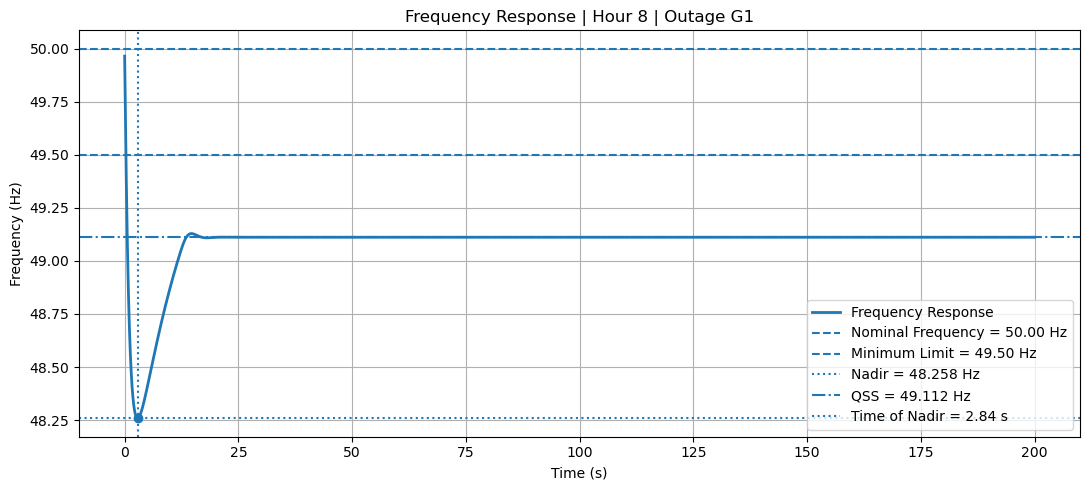

In [1326]:
# ============================================================
# 20. PLOT FREQUENCY RESPONSE
# ============================================================

time = freq_result["time"]
freq = freq_result["freq"]

nadir = freq_result["nadir"]
t_nadir = freq_result["t_nadir"]
qss = freq_result["qss"]

plt.figure(figsize=(11, 5))

plt.plot(time, freq, linewidth=2, label="Frequency Response")

plt.axhline(f0, linestyle="--", label=f"Nominal Frequency = {f0:.2f} Hz")
plt.axhline(f_min, linestyle="--", label=f"Minimum Limit = {f_min:.2f} Hz")
plt.axhline(nadir, linestyle=":", label=f"Nadir = {nadir:.3f} Hz")
plt.axhline(qss, linestyle="-.", label=f"QSS = {qss:.3f} Hz")

plt.axvline(t_nadir, linestyle=":", label=f"Time of Nadir = {t_nadir:.2f} s")

plt.scatter(t_nadir, nadir, zorder=5)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Frequency Response | Hour {t_uc} | Outage {freq_result['outage_g']}")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.show()

21-Plot PFR Response

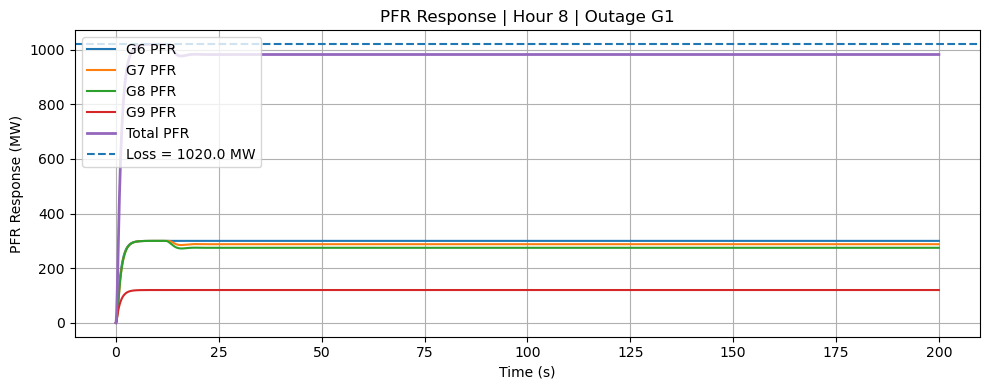

In [1327]:
# ============================================================
# 21. PLOT PFR RESPONSE
# ============================================================

plt.figure(figsize=(10, 4))

for g in freq_result["pfr_units"]:
    plt.plot(
        freq_result["time"],
        freq_result["pfr_history"][g],
        label=f"{g} PFR"
    )

plt.plot(
    freq_result["time"],
    freq_result["total_pfr_history"],
    linewidth=2,
    label="Total PFR"
)

plt.axhline(
    freq_result["loss"],
    linestyle="--",
    label=f"Loss = {freq_result['loss']:.1f} MW"
)

plt.xlabel("Time (s)")
plt.ylabel("PFR Response (MW)")
plt.title(f"PFR Response | Hour {t_uc} | Outage {freq_result['outage_g']}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

22-Rekap Frekuensi Semua Jam

In [1328]:
# ============================================================
# 22. ALL-HOUR FREQUENCY SUMMARY
# ============================================================
# Bagian ini menjalankan simulasi frekuensi untuk semua jam.
# Hasilnya dipakai untuk melihat jam mana yang paling kritis.

summary = []

for th in list(model.T):
    fr = simulate_frequency_response(
        model=model,
        t_uc=th,
        f0=f0,
        D_frac=D_frac,
        sim_time=sim_time,
        dt=dt
    )

    total_reserve = sum(value(model.R[g, th]) for g in model.G)
    total_pfr = sum(value(model.R_pfr[g, th]) for g in model.G)
    net_deficit = fr["loss"] - total_pfr
    pfr_ratio = total_pfr / fr["loss"] if fr["loss"] > 0 else 0

    summary.append([
        th,
        fr["outage_g"],
        round(fr["loss"], 2),
        round(total_reserve, 2),
        round(total_pfr, 2),
        round(net_deficit, 2),
        round(pfr_ratio * 100, 2),
        round(fr["nadir"], 4),
        round(fr["qss"], 4)
    ])

df_freq_summary = pd.DataFrame(summary, columns=[
    "t",
    "Unit Trip",
    "Ploss (MW)",
    "Total Reserve (MW)",
    "Total PFR (MW)",
    "Net Deficit (MW)",
    "PFR Ratio (%)",
    "f_nadir (Hz)",
    "f_steady (Hz)"
])

print("\n========== FREQUENCY ALL-HOUR SUMMARY ==========")
print(df_freq_summary.to_string(index=False))


========== FREQUENCY ALL-HOUR SUMMARY ==========
 t Unit Trip  Ploss (MW)  Total Reserve (MW)  Total PFR (MW)  Net Deficit (MW)  PFR Ratio (%)  f_nadir (Hz)  f_steady (Hz)
 1        G1       960.0               969.0             0.0             960.0            0.0       48.3700        49.1117
 2        G3       960.0               969.0             0.0             960.0            0.0       48.3987        49.1110
 3        G1       960.0               969.0             0.0             960.0            0.0       48.3627        49.1099
 4        G1       960.0               969.0             0.0             960.0            0.0       48.3583        49.1089
 5        G1       849.0               969.0             0.0             849.0            0.0       48.4876        49.1089
 6        G9       861.0               969.0             0.0             861.0            0.0       48.6343        49.2581
 7        G1       900.0               900.0             0.0             900.0           

23-Grafik Ringkasan Frekuensi

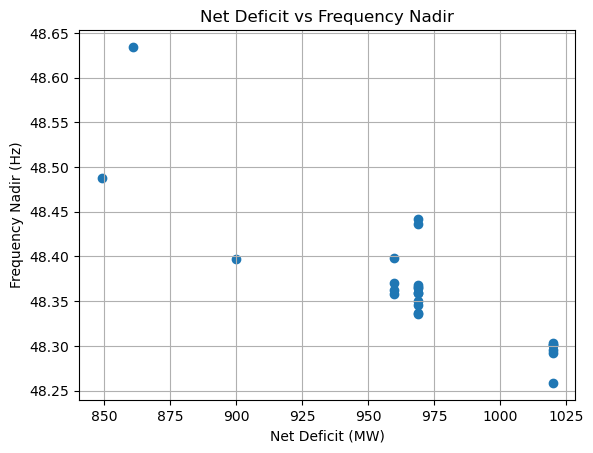

In [1329]:
# ============================================================
# 23. FREQUENCY SUMMARY PLOTS
# ============================================================

# Net deficit vs frequency nadir

plt.figure()

plt.scatter(
    df_freq_summary["Net Deficit (MW)"],
    df_freq_summary["f_nadir (Hz)"]
)

plt.xlabel("Net Deficit (MW)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("Net Deficit vs Frequency Nadir")
plt.grid()
plt.show()

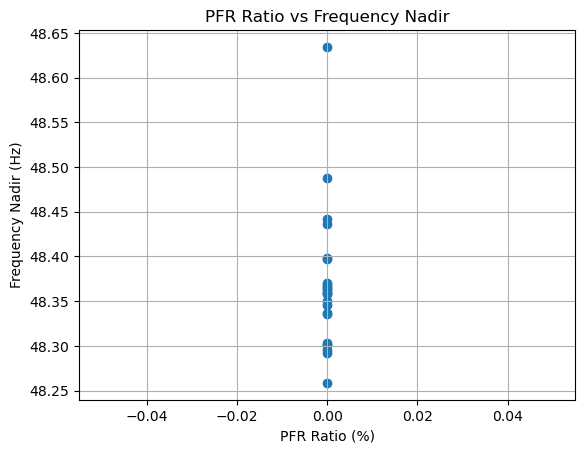

In [1330]:
# PFR ratio vs frequency nadir

plt.figure()

plt.scatter(
    df_freq_summary["PFR Ratio (%)"],
    df_freq_summary["f_nadir (Hz)"]
)

plt.xlabel("PFR Ratio (%)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("PFR Ratio vs Frequency Nadir")
plt.grid()
plt.show()

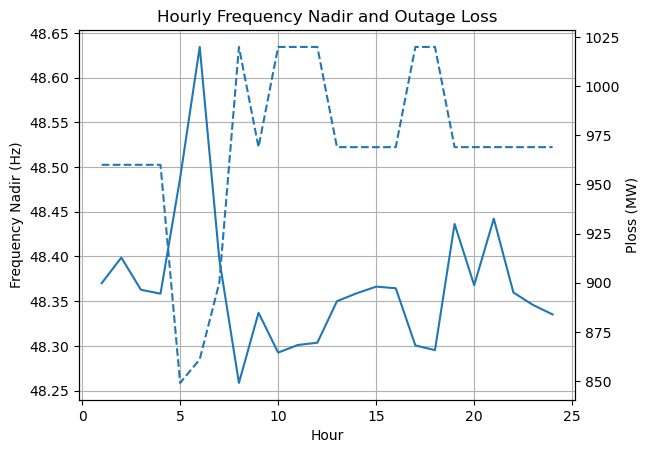

In [1331]:
# Trend nadir dan outage loss per jam

fig, ax1 = plt.subplots()

ax1.set_xlabel("Hour")
ax1.set_ylabel("Frequency Nadir (Hz)")
ax1.plot(df_freq_summary["t"], df_freq_summary["f_nadir (Hz)"])
ax1.grid()

ax2 = ax1.twinx()
ax2.set_ylabel("Ploss (MW)")
ax2.plot(df_freq_summary["t"], df_freq_summary["Ploss (MW)"], linestyle="--")

plt.title("Hourly Frequency Nadir and Outage Loss")
plt.show()

24-Plot UC Dispatch dan Status Unit

In [1332]:
# ============================================================
# 24. UC VISUALIZATION
# ============================================================

# Mapping nama unit agar legenda lebih mudah dibaca

name_map = {
    "G1": "PLTU 1",
    "G2": "PLTGU 1",
    "G3": "PLTU 2",
    "G4": "PLTUG 1",
    "G5": "PLTG 2",
    "G6": "PLTGU 2",
    "G7": "PLTGU 3",
    "G8": "PLTGU 4",
    "G9": "PLTU 3",
    "G10": "PLTU 4"
}

plot_labels = [name_map.get(g, g) for g in model.G]

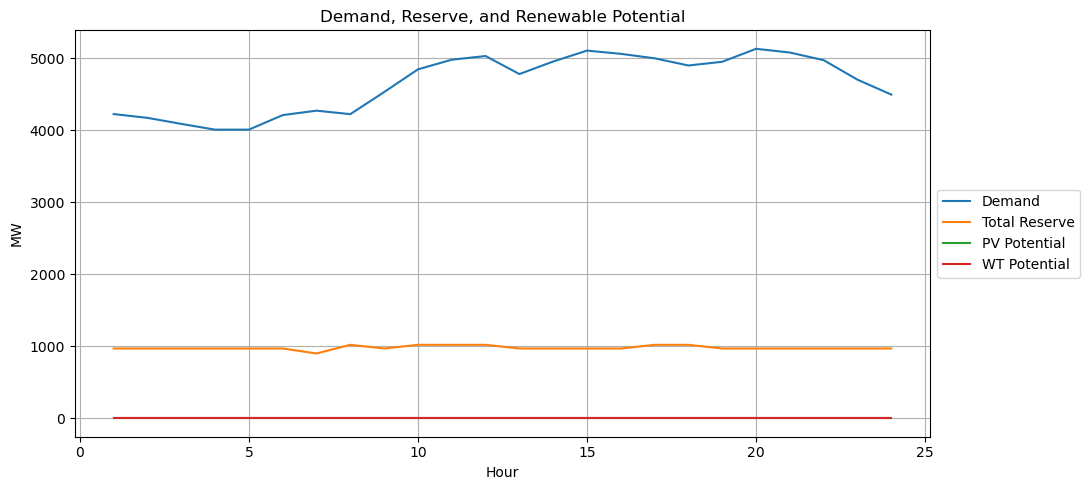

In [1333]:
# Demand, reserve, dan renewable potential

hours = list(model.T)

demand = [value(model.Demand[t]) for t in model.T]

total_reserve = [
    sum(value(model.R[g, t]) for g in model.G)
    for t in model.T
]

pv_potential = [
    sum(value(model.RenewPotential[g, t]) for g in model.G if Type[g] == "PV")
    for t in model.T
]

wt_potential = [
    sum(value(model.RenewPotential[g, t]) for g in model.G if Type[g] == "WT")
    for t in model.T
]

plt.figure(figsize=(11, 5))

plt.plot(hours, demand, label="Demand")
plt.plot(hours, total_reserve, label="Total Reserve")
plt.plot(hours, pv_potential, label="PV Potential")
plt.plot(hours, wt_potential, label="WT Potential")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Demand, Reserve, and Renewable Potential")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.grid()
plt.show()

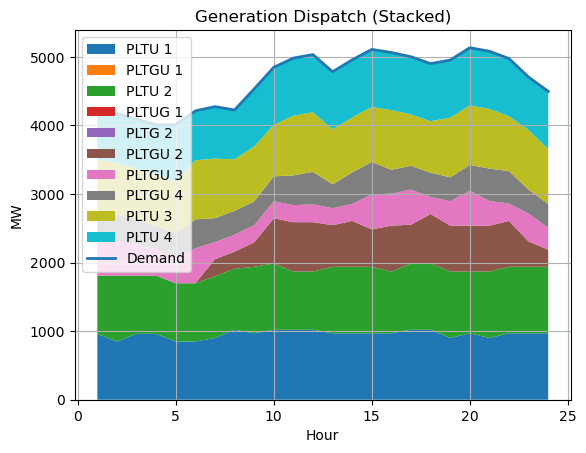

In [1334]:
# Dispatch per unit dalam bentuk stacked plot

gen_cols = [f"{g}_P" for g in model.G]

plt.figure()

plt.stackplot(
    df_hourly["Hour"],
    *[df_hourly[col] for col in gen_cols],
    labels=plot_labels
)

plt.plot(
    df_hourly["Hour"],
    df_hourly["Demand"],
    linewidth=2,
    label="Demand"
)

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Generation Dispatch (Stacked)")
plt.legend()
plt.grid()
plt.show()

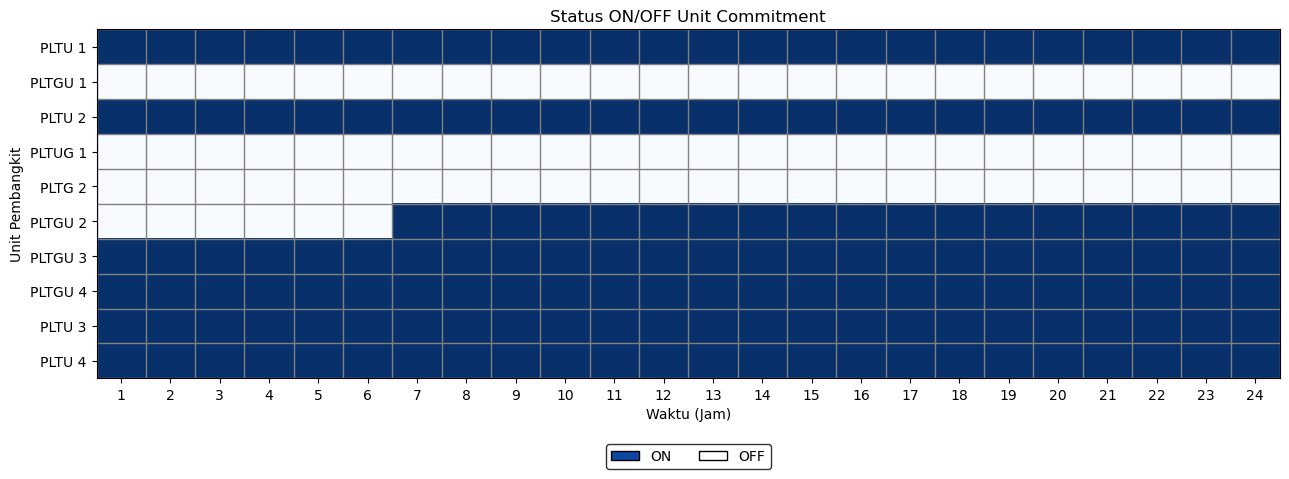

In [1335]:
# Status ON/OFF unit
gen_status_matrix = []

for g in model.G:
    gen_status_matrix.append([
        1 if value(model.u[g, t]) > 1e-4 else 0
        for t in model.T
    ])

matrix = np.array(gen_status_matrix)

# Nama unit
unit_labels = [name_map.get(g, g) for g in model.G]

plt.figure(figsize=(13, 5))

# Heatmap
plt.imshow(
    matrix,
    cmap="Blues",
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=1
)

# =========================
# AXIS
# =========================
plt.xticks(
    ticks=np.arange(len(list(model.T))),
    labels=list(model.T)
)

plt.yticks(
    ticks=np.arange(len(list(model.G))),
    labels=unit_labels
)

# =========================
# GRID ANTAR KOTAK
# =========================
ax = plt.gca()

# Minor ticks di batas sel
ax.set_xticks(np.arange(-0.5, len(list(model.T)), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(list(model.G)), 1), minor=True)

# Grid hanya untuk minor
ax.grid(
    which="minor",
    color="gray",
    linestyle="-",
    linewidth=1
)

# Hilangkan tampilan minor tick
ax.tick_params(which="minor", bottom=False, left=False)

# =========================
# LABEL & TITLE
# =========================
plt.xlabel("Waktu (Jam)")
plt.ylabel("Unit Pembangkit")
plt.title("Status ON/OFF Unit Commitment")

# =========================
# LEGEND ON/OFF
# =========================
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#0d47a1", edgecolor="black", label="ON"),
    Patch(facecolor="white", edgecolor="black", label="OFF")
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    frameon=True,
    edgecolor="black"
)

plt.tight_layout()

plt.show()